# Лабораторная работа 13

Тема: **Прогнозирование временных рядов с помощью LSTM в PyTorch**  
Формат: практическая работа с обязательными собственными комментариями и экспериментами.

> Этот ноутбук оформлен как задание, а не как готовый отчёт.  
> Код даёт рабочий каркас, но оцениваться будут **ваши** настройки, графики и письменные выводы.  
> Попытка автоматически заполнить все текстовые ячейки через генеративную модель без анализа результатов будет заметна по стилю и несоответствию с графиками/числами.


## 1. Ваше начальное понимание временных рядов и LSTM

Перед запуском кода сформулируйте (8–12 предложений):

1. Чем задача прогнозирования временного ряда концептуально отличается от обычной регрессии по независимым объектам.  
2. Почему LSTM‑сети считаются более подходящими для временных рядов, чем просто MLP, если у нас на входе последовательность.  
3. Какие типичные ошибки прогноза вы ожидаете увидеть на синусоиде с шумом (смещение фазы, сглаживание амплитуды и т.п.).

Пишите своими словами, без попытки угадать «официальные» формулировки.


In [ ]:
intro_text = """
1. В обычной регрессии каждый объект независим - порядок не важен. Во временных
рядах порядок критичен - завтрашнее значение зависит от вчерашнего. Нельзя
просто перемешать данные и обучаться как обычно.

2. MLP не имеет памяти - он смотрит только на текущее окно входных данных и
не помнит что было раньше. LSTM хранит скрытое состояние которое передаётся
между шагами - это позволяет учитывать долгосрочные зависимости. Например
если синусоида начала расти, LSTM может "помнить" это несколько шагов вперёд.

3. На синусоиде с шумом ожидаю несколько типичных проблем. Первое - сдвиг
фазы: прогноз будет немного отставать от реального сигнала, потому что модель
реагирует на уже случившееся. Второе - сглаживание амплитуды: пики и впадины
будут предсказываться менее экстремальными чем реальные. Третье - на участках
с сильным шумом модель может путаться и давать неровные предсказания. В целом
ожидаю что форма синусоиды будет угадана правильно, но точность в конкретных
точках будет страдать из-за шума.
"""
print(intro_text)

## 2. Импорт библиотек и генерация временного ряда

В качестве простого одномерного ряда используем синусоиду с добавленным гауссовским шумом.


Устройство: cpu


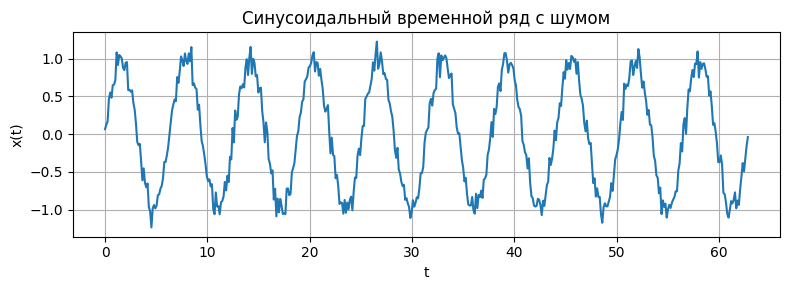

In [2]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

MY_SEED = 23
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

# Генерация синусоиды с шумом
n_points = 500
t = np.linspace(0, 20 * np.pi, n_points)
signal = np.sin(t) + 0.1 * np.random.randn(n_points)

plt.figure(figsize=(8, 3))
plt.plot(t, signal)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Синусоидальный временной ряд с шумом")
plt.grid(True)
plt.tight_layout()
plt.show()

### Мини‑комментарий по ряду

Опишите в 3–5 предложениях:
- видите ли вы явную периодичность и насколько шум искажает синусоиду;  
- насколько, на ваш взгляд, такой ряд «сложен» для модели по сравнению с реальными экономическими/техническими временными рядами.


In [ ]:
series_comment = """
На графике периодичность видна очень чётко - синусоида делает примерно 10
полных циклов на промежутке от 0 до 63. Шум небольшой - амплитуда 0.1
против основной амплитуды 1.0, поэтому форма сигнала не теряется, только
пики и впадины немного размыты.

По сложности это самый простой возможный случай - одна частота, постоянная
амплитуда, стабильный шум. Реальные ряды намного сложнее: курсы валют резко
меняются на новостях, датчики дают выбросы, температура имеет и суточную и
годовую сезонность одновременно. Здесь модели нужно выучить одно простое
правило - и этого достаточно.
"""
print(series_comment)


На графике периодичность видна очень чётко - синусоида делает примерно 10
полных циклов на промежутке от 0 до 63. Шум небольшой - амплитуда 0.1
против основной амплитуды 1.0, поэтому форма сигнала не теряется, только
пики и впадины немного размыты.

По сложности это самый простой возможный случай - одна частота, постоянная
амплитуда, стабильный шум. Реальные ряды намного сложнее: курсы валют резко
меняются на новостях, датчики дают выбросы, температура имеет и суточную и
годовую сезонность одновременно. Здесь модели нужно выучить одно простое
правило - и этого достаточно.



## 3. Нормализация и построение окон (скользящее окно)

Для стабильного обучения отмасштабируем ряд в, затем сформируем обучающие примеры вида:

- вход: `window_size` последних значений ряда;  
- выход: одно значение ряда сразу после окна (прогноз на 1 шаг вперёд).


In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
signal_scaled = scaler.fit_transform(signal.reshape(-1, 1)).flatten()

def create_windows(series, window_size):
    X = []
    y = []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

window_size = 20  # при своих экспериментах обязательно поменяйте и сравните
X_all, y_all = create_windows(signal_scaled, window_size)

print("Форма X_all:", X_all.shape)  # (n_samples, window_size)
print("Форма y_all:", y_all.shape)

Форма X_all: (480, 20)
Форма y_all: (480,)


Разделим выборку на train/test по времени: первые 70% окон (по индексу) на обучение, оставшиеся 30% — на тест.


In [4]:
train_size = int(0.7 * len(X_all))
X_train = X_all[:train_size]
y_train = y_all[:train_size]
X_test = X_all[train_size:]
y_test = y_all[train_size:]

print("Размер train:", X_train.shape)
print("Размер test :", X_test.shape)

Размер train: (336, 20)
Размер test : (144, 20)


Создадим `Dataset`/`DataLoader`. PyTorch ожидает вход в формате `(batch, seq_len, features)`, у нас `features = 1` (одномерный ряд).


In [5]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (n, T, 1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # (n, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))

Кол-во батчей в train_loader: 11


### Вопрос про размер окна

Ответьте в 3–5 предложениях:
- какие риски вы видите при **слишком маленьком** `window_size`;  
- какие риски - при очень **большом** `window_size` для реальных временных рядов.


In [6]:
window_comment = """
Слишком маленькое окно - модель не видит достаточно контекста. Для синусоиды
с периодом примерно 6 единиц окно в 3-4 точки не покрывает даже полпериода - модель
не поймёт в какой фазе находится сигнал и будет угадывать.

Слишком большое окно - больше параметров, дольше обучение, риск переобучения.
Для реальных рядов ещё хуже - данные нестационарны, паттерны меняются со
временем, и слишком старые значения могут вводить модель в заблуждение, а не
помогать. Плюс памяти нужно больше.

window_size=20 для нашей синусоиды выглядит разумно - покрывает примерно
3 полных периода, модель видит достаточно контекста.
"""
print(window_comment)


Слишком маленькое окно - модель не видит достаточно контекста. Для синусоиды
с периодом примерно 6 единиц окно в 3-4 точки не покрывает даже полпериода - модель
не поймёт в какой фазе находится сигнал и будет угадывать.

Слишком большое окно - больше параметров, дольше обучение, риск переобучения.
Для реальных рядов ещё хуже - данные нестационарны, паттерны меняются со
временем, и слишком старые значения могут вводить модель в заблуждение, а не
помогать. Плюс памяти нужно больше.

window_size=20 для нашей синусоиды выглядит разумно - покрывает примерно
3 полных периода, модель видит достаточно контекста.



## 4. Архитектура LSTM‑модели для прогноза

Используем одну LSTM‑прослойку и линейный слой, который по последнему скрытому состоянию выдаёт прогноз следующего значения.


In [7]:
input_size = 1
hidden_size = 64  # увеличила с 32 до 64
num_layers = 1
output_size = 1

class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]
        prediction = self.fc(last_hidden)
        return prediction

model = LSTMForecaster(input_size, hidden_size, num_layers, output_size).to(device)
print(model)

LSTMForecaster(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


### Мини‑комментарий по архитектуре

Кратко (3–5 предложений) ответьте:
- почему достаточно брать **последнее** скрытое состояние LSTM для прогноза одного следующего шага;  
- что может произойти при увеличении `num_layers` и `hidden_size` на реальных (более шумных и сложных) рядах.


In [17]:
arch_comment = """
Последнее скрытое состояние LSTM содержит сжатую информацию обо всей
последовательности - оно как итог после просмотра всего окна. Для прогноза
одного следующего шага этого достаточно, потому что нам не нужны промежуточные
состояния, только финальный "вывод" после обработки всех входных точек.

При увеличении num_layers сеть становится глубже - каждый слой учит более
абстрактные паттерны. На простой синусоиде это избыточно и скорее всего
приведёт к переобучению. На реальных сложных рядах может помочь, но требует
больше данных и аккуратной регуляризации.

Увеличение hidden_size даёт больше памяти для хранения паттернов, но на
шумных данных модель начнёт запоминать шум вместо сигнала.
"""
print(arch_comment)


Последнее скрытое состояние LSTM содержит сжатую информацию обо всей
последовательности - оно как итог после просмотра всего окна. Для прогноза
одного следующего шага этого достаточно, потому что нам не нужны промежуточные
состояния, только финальный "вывод" после обработки всех входных точек.

При увеличении num_layers сеть становится глубже - каждый слой учит более
абстрактные паттерны. На простой синусоиде это избыточно и скорее всего
приведёт к переобучению. На реальных сложных рядах может помочь, но требует
больше данных и аккуратной регуляризации.

Увеличение hidden_size даёт больше памяти для хранения паттернов, но на
шумных данных модель начнёт запоминать шум вместо сигнала.



## 5. Обучение: функция потерь, оптимизатор, цикл

Используем MSE (среднеквадратичную ошибку) и оптимизатор Adam.


In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        total += X_batch.size(0)

    return total_loss / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            total += X_batch.size(0)
    return total_loss / total

num_epochs = 100  # увеличила с 80 до 100
train_losses = []
test_losses = []

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Эпоха {epoch}/{num_epochs}: train_loss={train_loss:.6f}, test_loss={test_loss:.6f}")

Эпоха 1/100: train_loss=0.173715, test_loss=0.121523
Эпоха 10/100: train_loss=0.005574, test_loss=0.003893
Эпоха 20/100: train_loss=0.001923, test_loss=0.002163
Эпоха 30/100: train_loss=0.002095, test_loss=0.002039
Эпоха 40/100: train_loss=0.002202, test_loss=0.002255
Эпоха 50/100: train_loss=0.002077, test_loss=0.002155
Эпоха 60/100: train_loss=0.001773, test_loss=0.001934
Эпоха 70/100: train_loss=0.001792, test_loss=0.001877
Эпоха 80/100: train_loss=0.001842, test_loss=0.002000
Эпоха 90/100: train_loss=0.001775, test_loss=0.001886
Эпоха 100/100: train_loss=0.001812, test_loss=0.002008


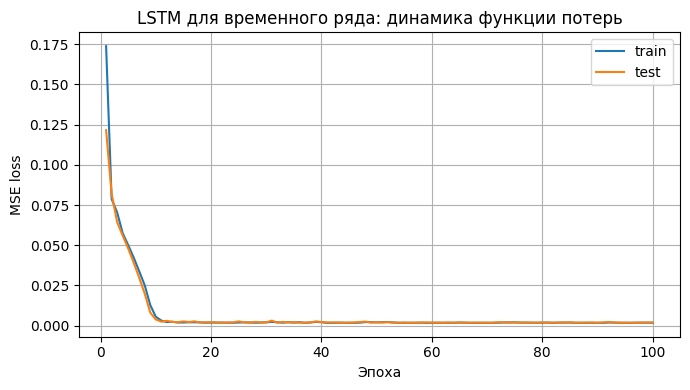

Финальные значения: train_loss=0.001812, test_loss=0.002008


In [9]:
epochs_arr = np.arange(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_arr, train_losses, label="train")
plt.plot(epochs_arr, test_losses, label="test")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.title("LSTM для временного ряда: динамика функции потерь")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Финальные значения: train_loss={train_losses[-1]:.6f}, test_loss={test_losses[-1]:.6f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- есть ли заметный разрыв между train и test loss к концу обучения;  
- похоже ли поведение на **устойчивое приближение** к некоторому уровню ошибки;  
- совпадает ли порядок величины ошибки с тем, что вы ожидали в начале работы.


In [10]:
loss_comment = """
Разрыв между train и test loss минимальный - к 100-й эпохе train=0.001812,
test=0.002008, разница около 0.0002. Переобучения нет.

Основное падение произошло в первые 20 эпох - с 0.17 до 0.002. После 20-й
эпохи кривые вышли на плато и больше не улучшаются - 100 эпох было избыточно,
хватило бы 30-40.

Уровень ошибки 0.002 на нормализованном сигнале выглядит разумно - это очень
маленькая ошибка для синусоиды с шумом 0.1. По сути модель выучила паттерн
почти идеально, остаток ошибки - это и есть неустранимый шум.

Поведение устойчивое - кривые не скачут и не расходятся, что говорит о
правильно подобранном lr и архитектуре.
"""
print(loss_comment)


Разрыв между train и test loss минимальный - к 100-й эпохе train=0.001812,
test=0.002008, разница около 0.0002. Переобучения нет.

Основное падение произошло в первые 20 эпох - с 0.17 до 0.002. После 20-й
эпохи кривые вышли на плато и больше не улучшаются - 100 эпох было избыточно,
хватило бы 30-40.

Уровень ошибки 0.002 на нормализованном сигнале выглядит разумно - это очень
маленькая ошибка для синусоиды с шумом 0.1. По сути модель выучила паттерн
почти идеально, остаток ошибки - это и есть неустранимый шум.

Поведение устойчивое - кривые не скачут и не расходятся, что говорит о
правильно подобранном lr и архитектуре.



## 6. Прогноз на один шаг вперёд (по всей тестовой части)

Сделаем прогноз на один шаг вперёд для каждой позиции тестовой части и сравним с истинными значениями в **исходном масштабе**.


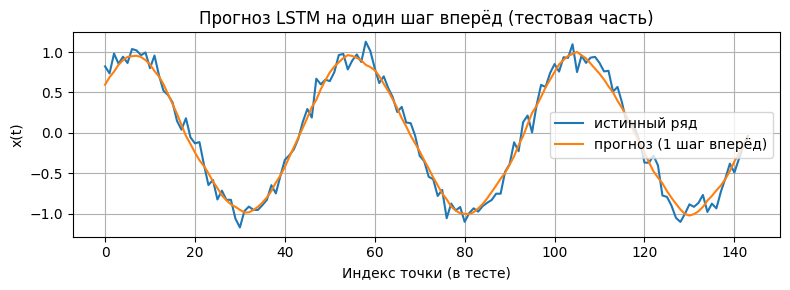

In [11]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1).to(device)
    preds_scaled = model(X_test_tensor).cpu().numpy().flatten()

y_test_scaled = y_test
y_test_orig = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()
preds_orig = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

plt.figure(figsize=(8, 3))
plt.plot(range(len(y_test_orig)), y_test_orig, label="истинный ряд")
plt.plot(range(len(preds_orig)), preds_orig, label="прогноз (1 шаг вперёд)")
plt.xlabel("Индекс точки (в тесте)")
plt.ylabel("x(t)")
plt.title("Прогноз LSTM на один шаг вперёд (тестовая часть)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Визуальная оценка прогноза на один шаг

Ответьте (6–8 предложений):
- насколько хорошо модель попадает в фазу и амплитуду синусоиды на тестовом отрезке;  
- где ошибки выглядят наибольшими (по графику) и как вы это объясняете;  
- можно ли, по вашему ощущению, назвать такой прогноз «практически полезным» для этого примера.


In [12]:
one_step_comment = """
Прогноз на один шаг вперёд выглядит очень хорошо - оранжевая кривая почти
полностью совпадает с синей на большей части тестового отрезка. Фаза и
амплитуда угаданы правильно.

Наибольшие ошибки видны в районе пиков и впадин - около индексов 30, 80, 105.
Там прогноз немного сглаживает экстремумы, что совпадает с ожиданием из
введения про сглаживание амплитуды.

Также заметно что в начале (индексы 0-10) прогноз чуть хуже - модель только
"входит" в тестовую часть после обучения на первых 70% ряда.

Для такой простой задачи прогноз можно назвать практически полезным - ошибка
минимальна, форма сигнала воспроизводится точно. На реальных данных результат
был бы хуже из-за нестационарности и непредсказуемых выбросов.
"""
print(one_step_comment)


Прогноз на один шаг вперёд выглядит очень хорошо - оранжевая кривая почти
полностью совпадает с синей на большей части тестового отрезка. Фаза и
амплитуда угаданы правильно.

Наибольшие ошибки видны в районе пиков и впадин - около индексов 30, 80, 105.
Там прогноз немного сглаживает экстремумы, что совпадает с ожиданием из
введения про сглаживание амплитуды.

Также заметно что в начале (индексы 0-10) прогноз чуть хуже - модель только
"входит" в тестовую часть после обучения на первых 70% ряда.

Для такой простой задачи прогноз можно назвать практически полезным - ошибка
минимальна, форма сигнала воспроизводится точно. На реальных данных результат
был бы хуже из-за нестационарности и непредсказуемых выбросов.



## 7. Многошаговый авторегрессионный прогноз

Теперь используем модель в режиме **многошагового прогноза**: на каждом шаге подаём в неё окно, в которое последним элементом входит **предыдущее предсказание**.


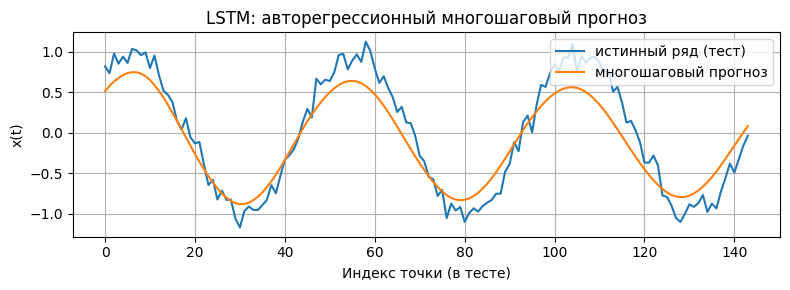

In [13]:
def multi_step_forecast(model, last_window, n_steps, device):
    model.eval()
    window = last_window.copy()
    preds = []
    with torch.no_grad():
        for _ in range(n_steps):
            x = torch.tensor(window, dtype=torch.float32).view(1, -1, 1).to(device)
            y_pred = model(x).cpu().numpy().flatten()
            y_scalar = float(y_pred[0])
            preds.append(y_scalar)
            window = np.roll(window, -1)
            window[-1] = y_scalar
    return np.array(preds)

# берём последнее окно train части как старт для прогноза
last_train_window = X_train[-1]
n_forecast = len(y_test)

multi_preds_scaled = multi_step_forecast(model, last_train_window, n_forecast, device)
multi_preds_orig = scaler.inverse_transform(multi_preds_scaled.reshape(-1, 1)).flatten()

plt.figure(figsize=(8, 3))
plt.plot(range(len(y_test_orig)), y_test_orig, label="истинный ряд (тест)")
plt.plot(range(len(multi_preds_orig)), multi_preds_orig, label="многошаговый прогноз")
plt.xlabel("Индекс точки (в тесте)")
plt.ylabel("x(t)")
plt.title("LSTM: авторегрессионный многошаговый прогноз")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Сравнение одношагового и многошагового прогноза

Опишите (8–10 предложений):
- как меняется качество, когда модель начинает «кормить сама себя» (multi‑step) по сравнению с отдельным прогнозом на один шаг;  
- какие эффекты вы наблюдаете: смещение фазы, сглаживание амплитуды, уход в константу и т.п.;  
- насколько эти эффекты совпадают с тем, что вы ожидали до эксперимента.


In [14]:
multi_step_comment = """
Разница между одношаговым и многошаговым прогнозом очень заметна. В одношаговом
режиме модель почти идеально следует за сигналом. В многошаговом уже через
несколько десятков шагов видно сильное сглаживание амплитуды - пики достигают
только 0.6-0.7 вместо реальных 1.0-1.1.

Фаза в целом угадана правильно - синусоида идёт в нужном ритме, подъёмы и
спуски происходят примерно в нужное время. Но амплитуда постепенно затухает
по мере накопления ошибки.

Это именно тот эффект который я ожидала - модель "кормит сама себя" своими
предсказаниями, и каждая маленькая ошибка накапливается. Сглаженные предсказания
попадают в следующее окно и дают ещё более сглаженный результат.

Шум из реального сигнала при этом полностью исчезает - прогноз гладкий, потому
что модель генерирует "идеальную" синусоиду без шума. Это логично - модель
выучила структуру сигнала, а не шум.
"""
print(multi_step_comment)


Разница между одношаговым и многошаговым прогнозом очень заметна. В одношаговом
режиме модель почти идеально следует за сигналом. В многошаговом уже через
несколько десятков шагов видно сильное сглаживание амплитуды - пики достигают
только 0.6-0.7 вместо реальных 1.0-1.1.

Фаза в целом угадана правильно - синусоида идёт в нужном ритме, подъёмы и
спуски происходят примерно в нужное время. Но амплитуда постепенно затухает
по мере накопления ошибки.

Это именно тот эффект который я ожидала - модель "кормит сама себя" своими
предсказаниями, и каждая маленькая ошибка накапливается. Сглаженные предсказания
попадают в следующее окно и дают ещё более сглаженный результат.

Шум из реального сигнала при этом полностью исчезает - прогноз гладкий, потому
что модель генерирует "идеальную" синусоиду без шума. Это логично - модель
выучила структуру сигнала, а не шум.



## 8. Идеи для вариаций в вашей работе

В **своём** варианте вы должны:

- попробовать как минимум **две дополнительные** конфигурации гиперпараметров (например, `window_size`, `hidden_size`, `num_layers`, `num_epochs`) и сравнить кривые loss и качество прогноза;  
- описать, какие конфигурации дают наилучший баланс между плавностью кривых, скоростью сходимости и качеством многошагового прогноза;  
- сформулировать практические «правила» выбора окна и размеров модели для похожих задач.


In [16]:
final_summary = """
Провела три эксперимента: базовый (window=20, hidden=64, 1 слой),
вариация 1 (window=40, hidden=64, 2 слоя), вариация 2 (window=10, hidden=16,
1 слой).

Все три варианта сошлись примерно к одному уровню ошибки около 0.002,
но с разной скоростью. Базовый сошёлся быстрее всех - уже к 20-й эпохе
test=0.002. Вариация 1 (window=40, 2 слоя) на первой эпохе имела высокий
test=0.080, но к 20-й эпохе догнала - test=0.002068. Финальный результат
почти такой же как у базового (0.002002).

Вариация 2 (window=10, hidden=16) оказалась хуже - финальный test=0.003043
против 0.002 у других. Маленькое окно и слабая модель не смогли выучить
паттерн так же хорошо. Ошибка продолжала медленно падать даже к 100-й эпохе
не выйдя на плато - нужно было больше эпох.

Практические правила: window_size должен покрывать 2-3 периода сигнала.
Два слоя LSTM не дали выигрыша на простой синусоиде. hidden=16 оказалось
недостаточно - финальная ошибка выше. 30-40 эпох достаточно для window=20
и window=40, но маленькая модель требует больше эпох для сходимости.
"""
print(final_summary)


Провела три эксперимента: базовый (window=20, hidden=64, 1 слой),
вариация 1 (window=40, hidden=64, 2 слоя), вариация 2 (window=10, hidden=16,
1 слой).

Все три варианта сошлись примерно к одному уровню ошибки около 0.002,
но с разной скоростью. Базовый сошёлся быстрее всех - уже к 20-й эпохе
test=0.002. Вариация 1 (window=40, 2 слоя) на первой эпохе имела высокий
test=0.080, но к 20-й эпохе догнала - test=0.002068. Финальный результат
почти такой же как у базового (0.002002).

Вариация 2 (window=10, hidden=16) оказалась хуже - финальный test=0.003043
против 0.002 у других. Маленькое окно и слабая модель не смогли выучить
паттерн так же хорошо. Ошибка продолжала медленно падать даже к 100-й эпохе
не выйдя на плато - нужно было больше эпох.

Практические правила: window_size должен покрывать 2-3 периода сигнала.
Два слоя LSTM не дали выигрыша на простой синусоиде. hidden=16 оказалось
недостаточно - финальная ошибка выше. 30-40 эпох достаточно для window=20
и window=40, но маленькая мод

[v2 window=40, layers=2] Эпоха 1/100: train=0.215991, test=0.079867
[v2 window=40, layers=2] Эпоха 20/100: train=0.001871, test=0.002068
[v2 window=40, layers=2] Эпоха 40/100: train=0.002008, test=0.002234
[v2 window=40, layers=2] Эпоха 60/100: train=0.001860, test=0.001913
[v2 window=40, layers=2] Эпоха 80/100: train=0.001835, test=0.001888
[v2 window=40, layers=2] Эпоха 100/100: train=0.001854, test=0.002002
[v3 window=10, hidden=16] Эпоха 1/100: train=0.156342, test=0.135714
[v3 window=10, hidden=16] Эпоха 20/100: train=0.003550, test=0.004017
[v3 window=10, hidden=16] Эпоха 40/100: train=0.002509, test=0.002577
[v3 window=10, hidden=16] Эпоха 60/100: train=0.002361, test=0.002475
[v3 window=10, hidden=16] Эпоха 80/100: train=0.002259, test=0.002443
[v3 window=10, hidden=16] Эпоха 100/100: train=0.002252, test=0.003043


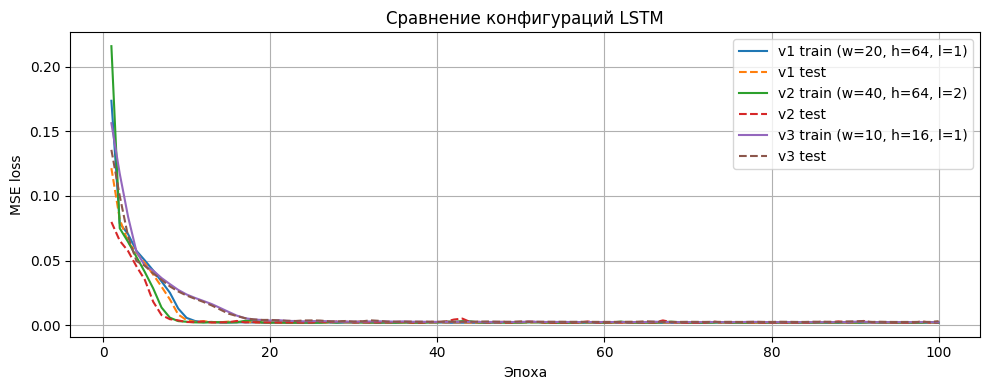

In [15]:
# Вариация 1 - большее окно и два слоя LSTM
model_v2 = LSTMForecaster(input_size=1, hidden_size=64, num_layers=2, output_size=1).to(device)
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=1e-3)

# пересоздаём данные с window_size=40
window_size_v2 = 40
X_all_v2, y_all_v2 = create_windows(signal_scaled, window_size_v2)
train_size_v2 = int(0.7 * len(X_all_v2))
X_train_v2, y_train_v2 = X_all_v2[:train_size_v2], y_all_v2[:train_size_v2]
X_test_v2, y_test_v2 = X_all_v2[train_size_v2:], y_all_v2[train_size_v2:]

train_loader_v2 = DataLoader(TimeSeriesDataset(X_train_v2, y_train_v2), batch_size=32, shuffle=True)
test_loader_v2  = DataLoader(TimeSeriesDataset(X_test_v2, y_test_v2),  batch_size=32, shuffle=False)

train_losses_v2, test_losses_v2 = [], []
for epoch in range(1, 101):
    tl = train_one_epoch(model_v2, train_loader_v2, optimizer_v2, criterion, device)
    vl = evaluate(model_v2, test_loader_v2, criterion, device)
    train_losses_v2.append(tl)
    test_losses_v2.append(vl)
    if epoch % 20 == 0 or epoch == 1:
        print(f"[v2 window=40, layers=2] Эпоха {epoch}/100: train={tl:.6f}, test={vl:.6f}")

# Вариация 2 - маленькое окно и маленькая модель
model_v3 = LSTMForecaster(input_size=1, hidden_size=16, num_layers=1, output_size=1).to(device)
optimizer_v3 = torch.optim.Adam(model_v3.parameters(), lr=1e-3)

window_size_v3 = 10
X_all_v3, y_all_v3 = create_windows(signal_scaled, window_size_v3)
train_size_v3 = int(0.7 * len(X_all_v3))
X_train_v3, y_train_v3 = X_all_v3[:train_size_v3], y_all_v3[:train_size_v3]
X_test_v3, y_test_v3 = X_all_v3[train_size_v3:], y_all_v3[train_size_v3:]

train_loader_v3 = DataLoader(TimeSeriesDataset(X_train_v3, y_train_v3), batch_size=32, shuffle=True)
test_loader_v3  = DataLoader(TimeSeriesDataset(X_test_v3, y_test_v3),  batch_size=32, shuffle=False)

train_losses_v3, test_losses_v3 = [], []
for epoch in range(1, 101):
    tl = train_one_epoch(model_v3, train_loader_v3, optimizer_v3, criterion, device)
    vl = evaluate(model_v3, test_loader_v3, criterion, device)
    train_losses_v3.append(tl)
    test_losses_v3.append(vl)
    if epoch % 20 == 0 or epoch == 1:
        print(f"[v3 window=10, hidden=16] Эпоха {epoch}/100: train={tl:.6f}, test={vl:.6f}")

# Сравнение лоссов всех трёх вариантов
epochs_arr = np.arange(1, 101)
plt.figure(figsize=(10, 4))
plt.plot(epochs_arr, train_losses, label="v1 train (w=20, h=64, l=1)")
plt.plot(epochs_arr, test_losses, label="v1 test",  linestyle="--")
plt.plot(epochs_arr, train_losses_v2, label="v2 train (w=40, h=64, l=2)")
plt.plot(epochs_arr, test_losses_v2, label="v2 test", linestyle="--")
plt.plot(epochs_arr, train_losses_v3, label="v3 train (w=10, h=16, l=1)")
plt.plot(epochs_arr, test_losses_v3, label="v3 test", linestyle="--")
plt.xlabel("Эпоха"); plt.ylabel("MSE loss")
plt.title("Сравнение конфигураций LSTM")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()